In [3]:
import pandas as pd
import numpy as np
import hdbscan
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("./data/real_estate.csv")
df.head()

,id,city,bhk,price_lakh,area_sqft,dist_center_km,amenity_score,segment
0,1,Bangalore,3,110.8,1300,15.1,7.4,Mid-Range
1,2,Nashik,3,189.9,2077,2.6,8.8,Luxury
2,3,Bangalore,1,35.8,628,20.8,4.6,Budget
3,4,Hyderabad,2,75.3,1170,11.2,6.0,Mid-Range
4,5,Bangalore,3,78.8,1040,14.2,6.1,Mid-Range


In [5]:
features = ['price_lakh', 'area_sqft', 'dist_center_km', 'amenity_score']
X = df[features]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# HDBSCAN

hdbs = hdbscan.HDBSCAN(
    min_cluster_size = 8  # minimum no. of points to form a cluster
)

df['cluster'] = hdbs.fit_predict(X_scaled)

In [9]:
n_clusters = df['cluster'].nunique() - (1 if -1 in df['cluster'].values else 0)
n_noise    = (df['cluster'] == -1).sum()
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")
print(f"\n{df['cluster'].value_counts().sort_index()}")

Clusters found : 3
Noise points   : 3

cluster
-1     3
 0    50
 1    38
 2    59
Name: count, dtype: int64


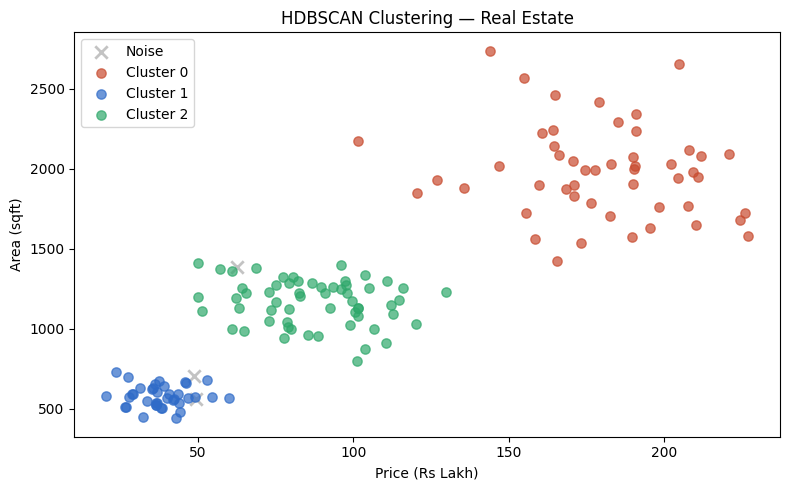

In [10]:
colors  = {-1: '#aaa', 0: '#c84b2f', 1: '#2f6bc8', 2: '#2fa86b', 3: '#c8902f'}
markers = {-1: 'x'}

plt.figure(figsize=(8, 5))
for c, grp in df.groupby('cluster'):
    is_noise = c == -1
    plt.scatter(
        grp['price_lakh'], grp['area_sqft'],
        color=colors.get(c, '#999'),
        marker='x' if is_noise else 'o',
        s=80 if is_noise else 45,
        linewidths=2 if is_noise else 1,
        alpha=0.7,
        label='Noise' if is_noise else f'Cluster {c}'
    )

plt.xlabel('Price (Rs Lakh)')
plt.ylabel('Area (sqft)')
plt.title('HDBSCAN Clustering — Real Estate')
plt.legend()
plt.tight_layout()
plt.show()